<a href="https://colab.research.google.com/github/GayatriVidhate23/Pattern-Recognition-/blob/main/Practical_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from skimage.feature import hog

In [4]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

with h5py.File('usps.h5','r') as hf:

    train = hf.get('train')

    X_train = train.get('data')[:]
    y_train = train.get('target')[:]

    test = hf.get('test')

    X_test = test.get('data')[:]
    y_test = test.get('target')[:]

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (7291, 256)
Testing Images : (2007, 256)


In [5]:
X_train = X_train.reshape(-1,16,16)
X_test = X_test.reshape(-1,16,16)

print(X_train.shape)
print(X_test.shape)

(7291, 16, 16)
(2007, 16, 16)


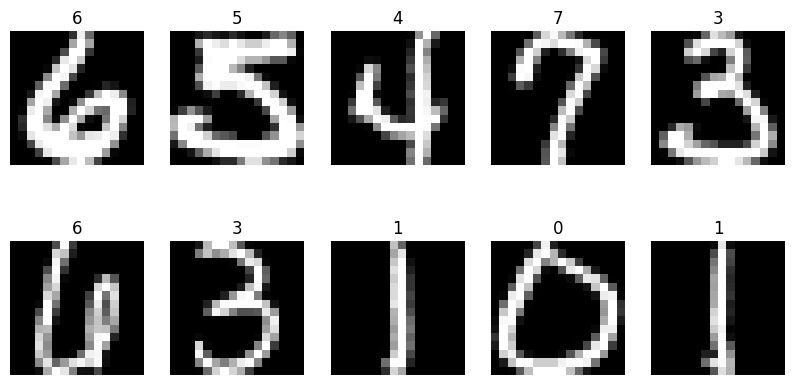

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(int(y_train[i]))
    plt.axis('off')

plt.show()

In [7]:
hog_train = []

for image in X_train:

    feature = hog(image,
                  orientations=9,
                  pixels_per_cell=(4,4),
                  cells_per_block=(2,2),
                  visualize=False)

    hog_train.append(feature)

hog_train = np.array(hog_train)

print(hog_train.shape)

(7291, 324)


In [8]:
hog_test = []

for image in X_test:

    feature = hog(image,
                  orientations=9,
                  pixels_per_cell=(4,4),
                  cells_per_block=(2,2),
                  visualize=False)

    hog_test.append(feature)

hog_test = np.array(hog_test)

print(hog_test.shape)

(2007, 324)


In [9]:
svm = SVC(kernel='rbf')

svm.fit(hog_train, y_train)

SVC()

In [10]:
prediction = svm.predict(hog_test)

In [11]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy =", accuracy*100,"%")

Accuracy = 96.21325361235675 %


In [12]:
cm = confusion_matrix(y_test, prediction)

print(cm)

[[354   1   2   0   0   1   0   0   0   1]
 [  0 258   0   0   3   0   3   0   0   0]
 [  4   0 189   3   1   0   0   1   0   0]
 [  1   0   1 155   0   5   1   0   3   0]
 [  0   1   1   0 189   1   2   1   0   5]
 [  1   0   1   4   0 154   0   0   0   0]
 [  0   0   1   0   3   4 162   0   0   0]
 [  0   1   2   0   4   0   0 140   0   0]
 [  2   0   0   3   1   1   1   1 155   2]
 [  0   0   0   0   0   0   0   1   1 175]]


In [13]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       359
           1       0.99      0.98      0.98       264
           2       0.96      0.95      0.96       198
           3       0.94      0.93      0.94       166
           4       0.94      0.94      0.94       200
           5       0.93      0.96      0.94       160
           6       0.96      0.95      0.96       170
           7       0.97      0.95      0.96       147
           8       0.97      0.93      0.95       166
           9       0.96      0.99      0.97       177

    accuracy                           0.96      2007
   macro avg       0.96      0.96      0.96      2007
weighted avg       0.96      0.96      0.96      2007



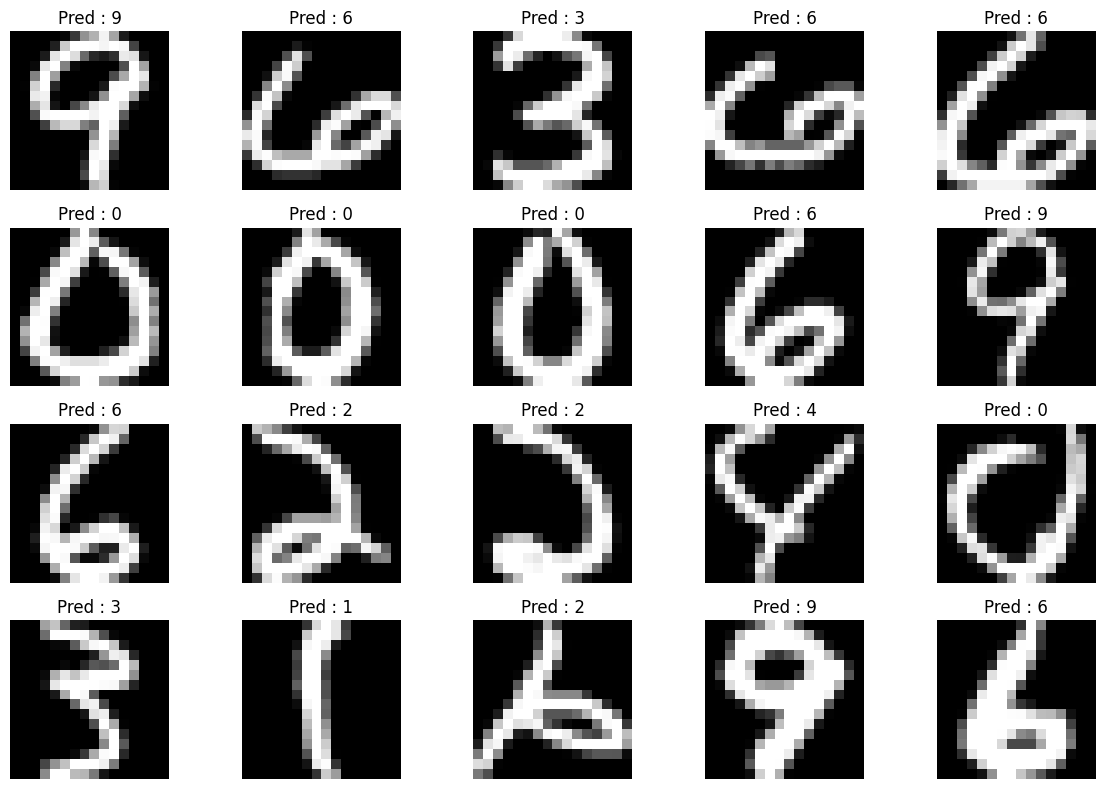

In [14]:
plt.figure(figsize=(12,8))

for i in range(20):

    plt.subplot(4,5,i+1)
    plt.imshow(X_test[i], cmap='gray')

    plt.title("Pred : {}".format(int(prediction[i])))

    plt.axis('off')

plt.tight_layout()

plt.show()